In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Hide warning messages for cleaner output.
warnings.filterwarnings('ignore')

# Set the default style for all plots.
sns.set_style('whitegrid')

# Set the default figure size for all plots.
plt.rcParams['figure.figsize'] = (12, 6)

# Confirm that all libraries were imported successfully.
print("Libraries imported successfully!")

Libraries imported successfully!


In [84]:
# Load the dataset from a CSV file.
df = pd.read_csv('/content/resumeJD_pairs.csv', engine='python', on_bad_lines='skip')

# Display the number of rows and columns in the dataset.
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Display the names of all columns.
print(f"\nColumns: {list(df.columns)}")

Data Loaded Successfully: 5,099 rows, 4 columns

Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [85]:
# First look at the data
print("First 5 rows:")
df.head()

First 5 rows:


,resume_text,job_description,match_score,match_label
0,SummaryI am seeking a position wherein I may u...,- Share resume to shan imrsoft.com Job Title ...,0.81,high
1,ProfileHighly motivated Sales Associate with e...,Purpose StatementThe Software Engineering Man...,0.24,low
2,SummaryHaving achieved a milestone of 7 years ...,"Title Business AnalystLocation Santa Clara, C...",0.54,medium
3,SummaryWireless communications engineer with e...,Job Description As a Principal Software Engin...,0.52,medium
4,SummaryData Entry experienced and adept at inp...,"Title Data EngineerLocation fully remote, how...",0.59,medium


In [86]:
# Display basic information about the dataset.
print("Dataset Info:")

# Print a separator line for better readability.
print("=" * 60)

# Show column names, data types, and missing values.
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      5099 non-null   object 
 1   job_description  5099 non-null   object 
 2   match_score      5099 non-null   float64
 3   match_label      5099 non-null   object 
dtypes: float64(1), object(3)
memory usage: 159.5+ KB


In [87]:
# statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,match_score
count,5099.000000
mean,0.471847
std,0.249741
min,0.190000
25%,0.250000
50%,0.300000
75%,0.600000
max,0.900000


In [88]:
# text columns summary
print("\nText Columns Summary:")
df.describe(include='object')


Text Columns Summary:


,resume_text,job_description,match_label
count,5099,5099,5099
unique,735,310,3
top,SummaryFinancial Accountant specializing in fi...,Calling all innovators find your future at Fi...,low
freq,57,98,2565


In [89]:
# Analyze missing values in each column.
print("Missing Values Analysis:")

# Print a separator line for better readability.
print("=" * 60)

# Count missing values in each column.
missing = df.isnull().sum()

# Calculate the percentage of missing values.
missing_pct = (missing / len(df)) * 100

# Create a summary table for missing values.
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})

# Display the missing values summary.
print(missing_df)

# Display the total number of missing values.
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                  0         0.0
job_description              0         0.0
match_score                  0         0.0
match_label                  0         0.0

Total missing values: 0


In [90]:
# Count completely duplicate rows in the dataset.
full_dupes = df.duplicated().sum()

# Display the total number of duplicate rows.
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 0


In [91]:
# Count duplicate resume and job description pairs.
pair_dupes = df.duplicated(subset=['resume_text', 'job_description']).sum()

# Display the total number of duplicate pairs.
print(f"Duplicate resume+JD pairs: {pair_dupes}")

Duplicate resume+JD pairs: 0


In [92]:
# Display all duplicate resume and job description pairs.
print("\nDuplicate rows:")

# Show duplicate rows while keeping all occurrences.
df[df.duplicated(subset=['resume_text', 'job_description'], keep=False)]


Duplicate rows:


,resume_text,job_description,match_score,match_label


In [93]:
# Display all duplicate resume and job description pairs.
print("\nDuplicate rows:")

# Show duplicate rows while keeping all occurrences.
df[df.duplicated(subset=['resume_text','match_label'], keep=False)]


Duplicate rows:


,resume_text,job_description,match_score,match_label
0,SummaryI am seeking a position wherein I may u...,- Share resume to shan imrsoft.com Job Title ...,0.81,high
1,ProfileHighly motivated Sales Associate with e...,Purpose StatementThe Software Engineering Man...,0.24,low
2,SummaryHaving achieved a milestone of 7 years ...,"Title Business AnalystLocation Santa Clara, C...",0.54,medium
3,SummaryWireless communications engineer with e...,Job Description As a Principal Software Engin...,0.52,medium
5,SummaryHaving achieved a milestone of 7 years ...,"Pay Range 81k - 102k, depending on experience...",0.28,low
...,...,...,...,...
5094,Experience10 2019to06 2019Data AnalystAngi Hom...,Job Description W2 positions (Marketing)We ar...,0.26,low
5095,SummaryHaving achieved a milestone of 7 years ...,We are looking for an experienced engineer wh...,0.56,medium
5096,Professional SummaryRELATED KNOWLEDGE AND SKIL...,Experienced in Salesforce Industries Communic...,0.27,low
5097,SummaryObtain a position where I can utilize m...,Organization Overview Manomin Resawn Timbers ...,0.22,low


In [94]:

# Check the uniqueness of resumes, job descriptions, and their pairs.

# Display the total number of rows.
print(f"Total rows:          {len(df)}")

# Display the number of unique resumes.
print(f"Unique resumes:      {df['resume_text'].nunique()}")

# Display the number of unique job descriptions.
print(f"Unique JDs:          {df['job_description'].nunique()}")

# Display the number of unique resume and job description pairs.
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")

Total rows:          5099
Unique resumes:      735
Unique JDs:          310
Unique resume+JD pairs: 5099


In [95]:
# Check the consistency of values in the match label column.

# Display the count of each unique label.
print("Unique labels found:")
print(df['match_label'].value_counts())

# Display the number of unique labels.
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")

# Display all distinct label values.
print("Distinct values:", df['match_label'].unique())

Unique labels found:
match_label
low       2565
medium    1273
high      1261
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['high' 'low' 'medium']


In [96]:
# Display summary statistics for match scores.
print("Score distribution:")
print(df['match_score'].describe())
print()

# Find scores outside the valid range (0 to 1).
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]

# Display the number of invalid scores.
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")

# Show the labels and values of invalid scores.
print(invalid_scores[['match_label', 'match_score']])

Score distribution:
count    5099.000000
mean        0.471847
std         0.249741
min         0.190000
25%         0.250000
50%         0.300000
75%         0.600000
max         0.900000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []


In [97]:
# Check whether match scores align with their labels.

print("Score stats per label (after lowercasing):")

# Convert labels to lowercase for consistent grouping.
df['match_label_lower'] = df['match_label'].str.lower()

# Display score statistics for each label.
print(df.groupby('match_label_lower')['match_score'].describe().round(2))

# Expected score ranges:
# high   → 0.75 – 0.95
# medium → 0.40 – 0.70
# low    → 0.05 – 0.35

Score stats per label (after lowercasing):
                    count  mean   std   min   25%   50%   75%  max
match_label_lower                                                 
high               1261.0  0.85  0.03  0.79  0.82  0.85  0.87  0.9
low                2565.0  0.25  0.03  0.19  0.22  0.25  0.27  0.3
medium             1273.0  0.55  0.03  0.50  0.52  0.55  0.57  0.6


In [98]:
# Check for missing values in each column.
print("Missing values per column:")
print(df.isnull().sum())
print()

# Find rows that contain at least one missing value.
nulls = df[df.isnull().any(axis=1)]

# Display the total number of rows with missing values.
print(f"Rows with at least one null: {len(nulls)}")

# Show the first 10 rows with missing match labels or scores.
nulls[['match_label', 'match_score']].head(10)

Missing values per column:
resume_text          0
job_description      0
match_score          0
match_label          0
match_label_lower    0
dtype: int64

Rows with at least one null: 0


,match_label,match_score


In [99]:
# Display a summary of all data quality checks.
print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)

# Display the total number of rows.
print(f"  Total rows:             {len(df)}")

# Display the number of completely duplicate rows.
print(f"  Full duplicates:        {df.duplicated().sum()}")

# Display the number of duplicate resume and job description pairs.
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")

# Display the number of missing resume entries.
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")

# Display the number of missing job descriptions.
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")

# Display the number of unique label values.
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")

# Display the number of scores outside the valid range.
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             5099
  Full duplicates:        0
  Duplicate pairs:        0
  Null resume_text:       0
  Null job_description:   0
  Label case variants:    3 (expected 3)
  Invalid scores (<0/>1): 0


In [100]:
# Display the proportion of each match label.
print(df['match_label'].value_counts(normalize=True).round(2))

match_label
low       0.50
medium    0.25
high      0.25
Name: proportion, dtype: float64


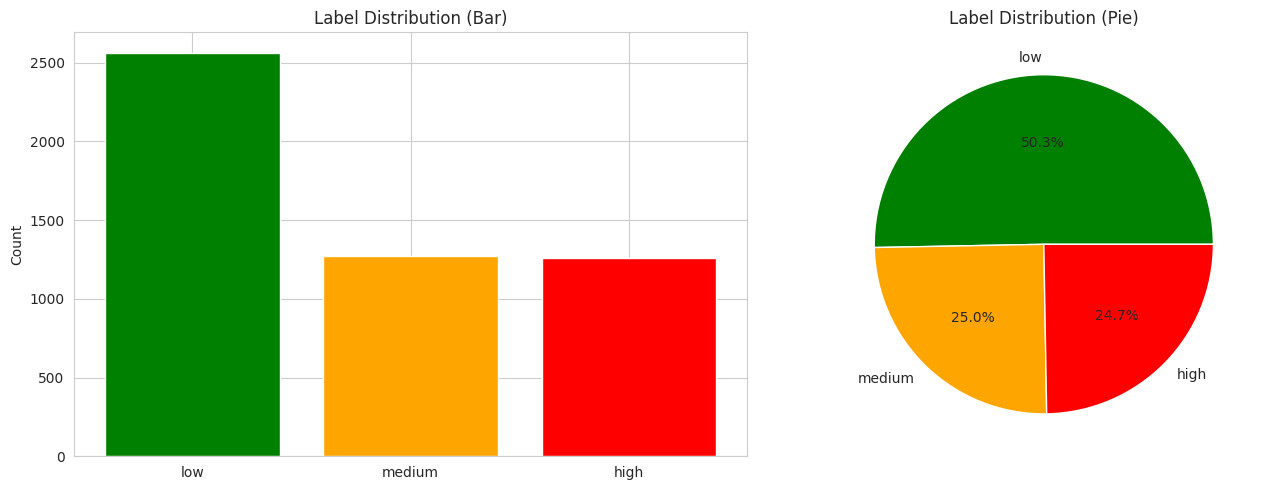

In [101]:
# Create side-by-side bar and pie charts for label distribution.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count the number of records for each label.
counts = df['match_label'].str.lower().value_counts()

# Create a bar chart of label counts.
axes[0].bar(counts.index, counts.values, color=['green', 'orange', 'red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

# Create a pie chart showing the label proportions.
axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=['green', 'orange', 'red']
)
axes[1].set_title('Label Distribution (Pie)')

# Adjust spacing between the plots.
plt.tight_layout()

# Display the charts.
plt.show()

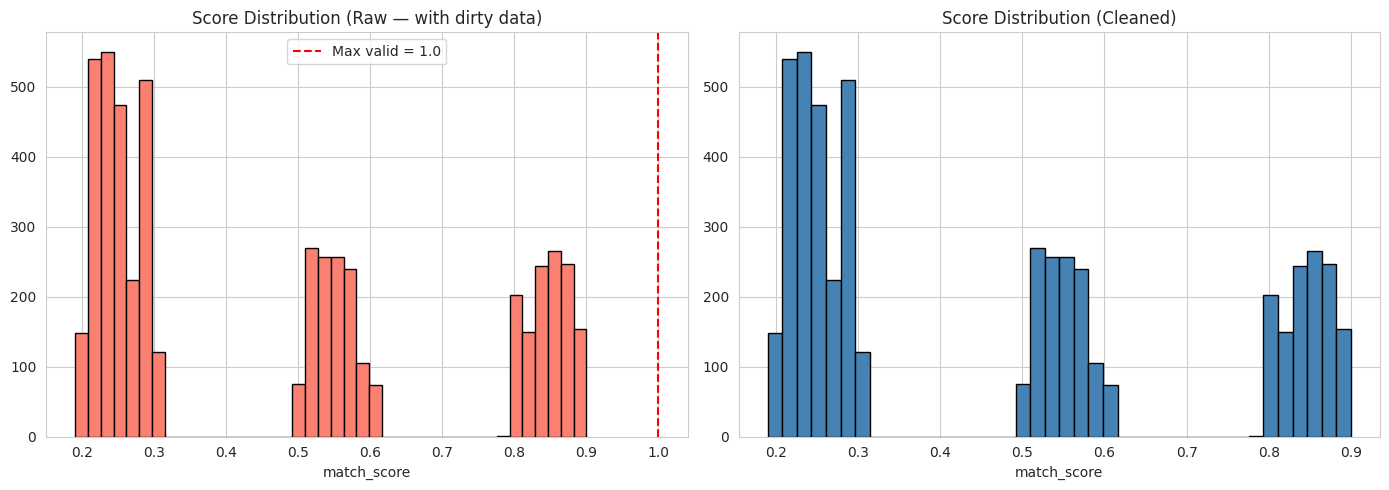

In [102]:
# Create side-by-side histograms for raw and cleaned match scores.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the distribution of all match scores.
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')

# Mark the maximum valid score.
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# Keep only scores within the valid range (0–1).
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]

# Plot the distribution after removing invalid scores.
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

# Adjust spacing between the plots.
plt.tight_layout()

# Display the histograms.
plt.show()

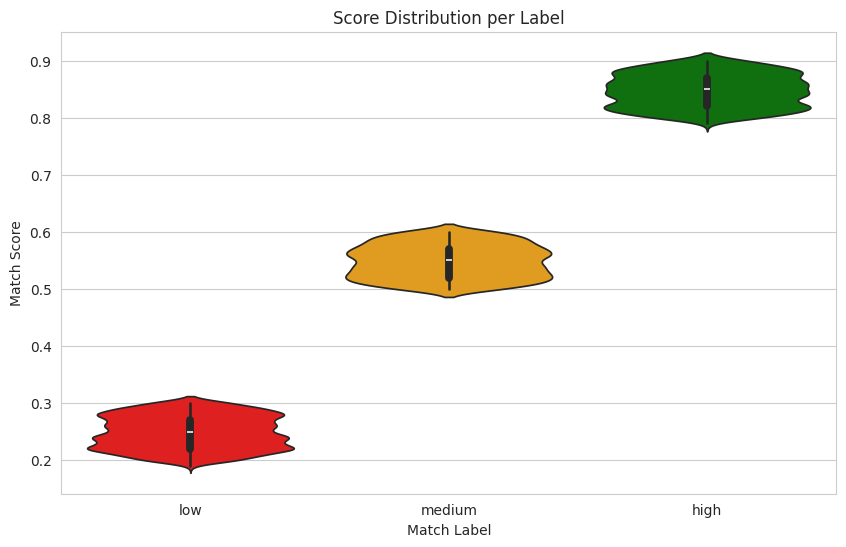

In [103]:
import seaborn as sns

# Create a copy of the dataset for visualization.
df_plot = df.copy()

# Convert labels to lowercase for consistency.
df_plot['match_label'] = df_plot['match_label'].str.lower()

# Keep only rows with valid match scores.
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

# Create a figure for the violin plot.
plt.figure(figsize=(10, 6))

# Show the score distribution for each match label.
sns.violinplot(
    data=df_plot,
    x='match_label',
    y='match_score',
    order=['low', 'medium', 'high'],
    palette=['red', 'orange', 'green']
)

# Set the chart title.
plt.title('Score Distribution per Label')

# Label the x-axis.
plt.xlabel('Match Label')

# Label the y-axis.
plt.ylabel('Match Score')

# Display the plot.
plt.show()

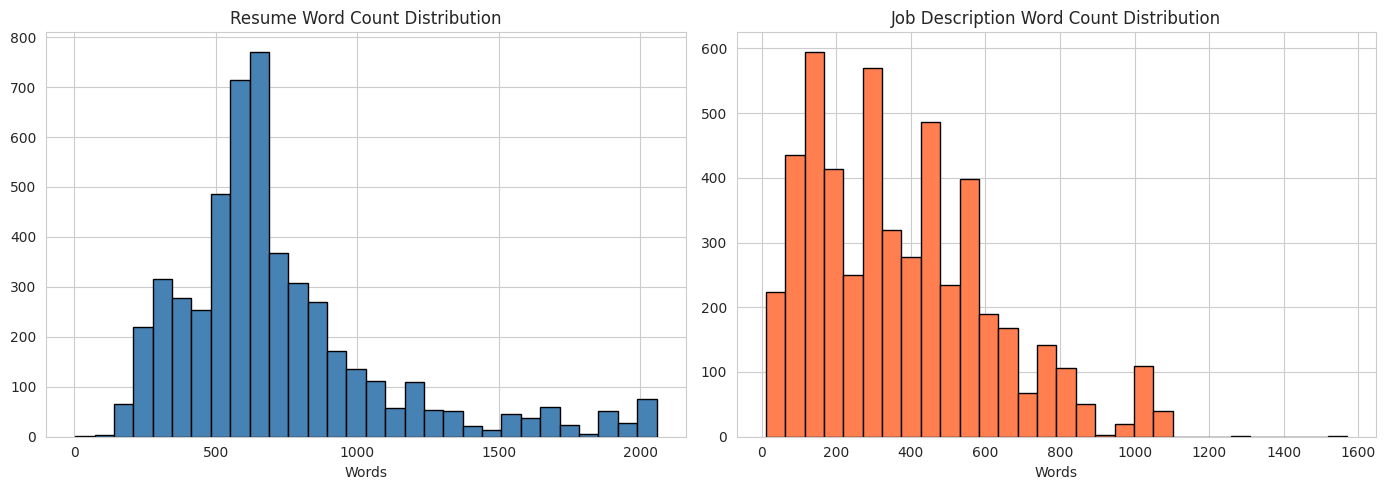

In [104]:
# Calculate the word count for each resume.
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()

# Calculate the word count for each job description.
df_plot['jd_len'] = df_plot['job_description'].str.split().str.len()

# Create side-by-side histograms.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the distribution of resume word counts.
axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

# Plot the distribution of job description word counts.
axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

# Adjust spacing between the plots.
plt.tight_layout()

# Display the histograms.
plt.show()

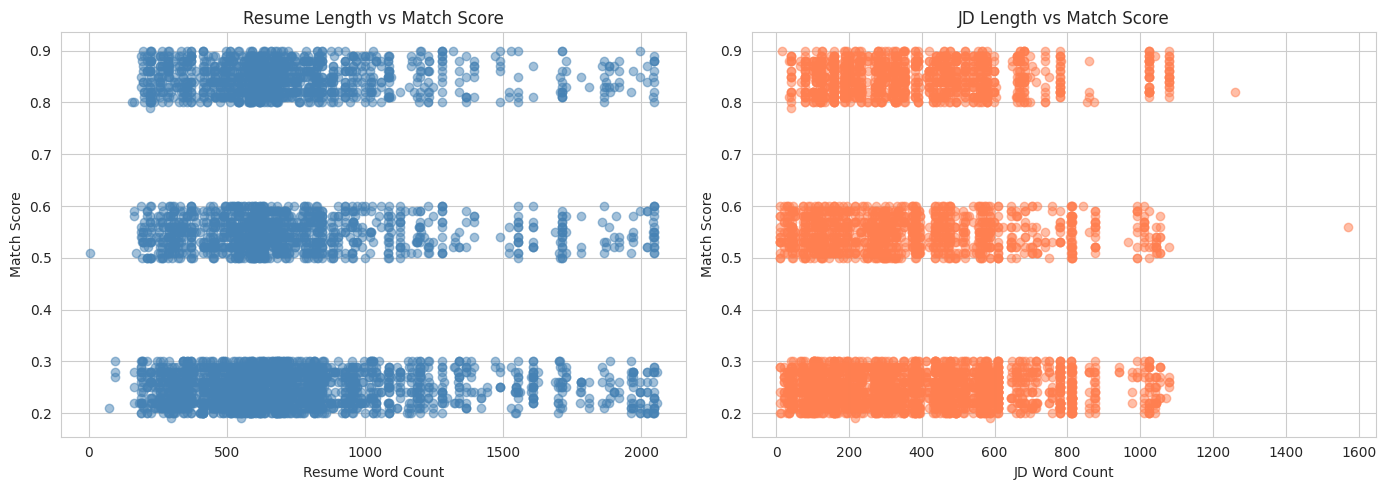

Resume length correlation: -0.005
JD length correlation:     0.021


In [105]:

# Create side-by-side scatter plots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot resume length against match score.
axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

# Plot job description length against match score.
axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

# Adjust spacing between the plots.
plt.tight_layout()

# Display the scatter plots.
plt.show()

# Calculate the correlation between resume length and match score.
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))

# Calculate the correlation between job description length and match score.
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))


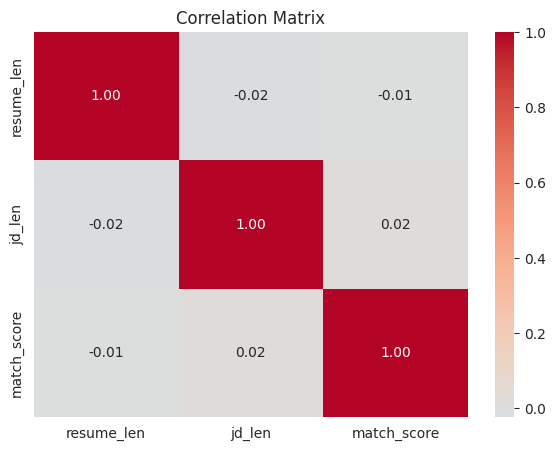

In [106]:
# Create a figure for the correlation heatmap.
plt.figure(figsize=(7, 5))

# Calculate the correlation between numerical features.
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()

# Display the correlation matrix as a heatmap.
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)

# Set the chart title.
plt.title('Correlation Matrix')

# Display the heatmap.
plt.show()

In [108]:
pip install wordcloud

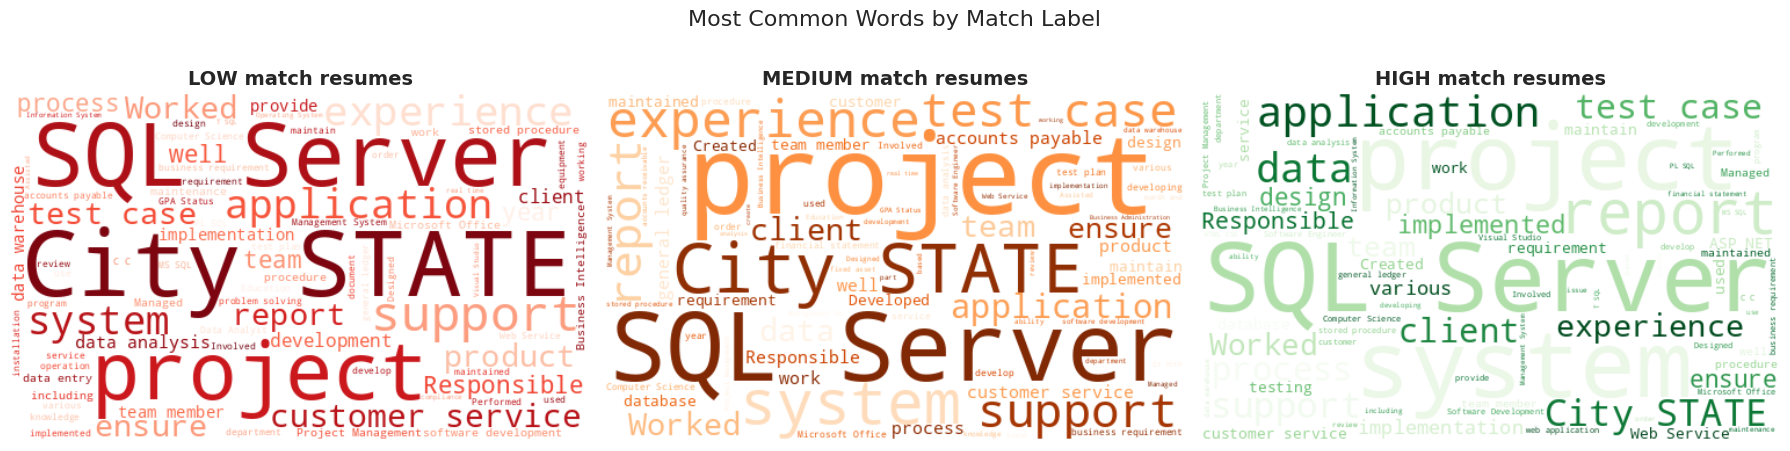

In [109]:
# Import the WordCloud class to generate text-based visualizations.
from wordcloud import WordCloud

# Create a figure with three subplots to compare word clouds
# for low, medium, and high match resumes.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define the match labels and their corresponding color themes.
labels = ['low', 'medium', 'high']
colors = ['Reds', 'Oranges', 'Greens']

# Generate a separate word cloud for each match category.
for ax, label, cmap in zip(axes, labels, colors):

    # Combine all resume text belonging to the current match label
    # into a single string for word frequency analysis.
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())

    # Generate a word cloud where larger words appear more frequently
    # in resumes of the selected match category.
    wc = WordCloud(
        width=500,
        height=300,
        background_color='white',
        colormap=cmap,
        max_words=80
    ).generate(text)

    # Display the generated word cloud.
    ax.imshow(wc, interpolation='bilinear')

    # Hide the axis since it is not needed for a word cloud.
    ax.axis('off')

    # Add the match category as the subplot title.
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

# Add an overall title describing the comparison.
plt.suptitle('Most Common Words by Match Label', fontsize=16)

# Adjust spacing so all subplots fit neatly.
plt.tight_layout()

# Display the complete word cloud comparison.
plt.show()

In [110]:
# Display a summary of the dataset before applying any cleaning operations.
# This baseline helps compare the data quality before and after preprocessing.
print("BEFORE CLEANING")
print("=" * 40)

# Show the total number of records currently available in the dataset.
print(f"Total rows:       {len(df)}")

# Count missing resume entries that may affect text analysis or model training.
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")

# Count missing job descriptions, as they are required for resume-job matching.
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")

# Identify completely duplicate rows that may introduce redundant information.
print(f"Duplicates:       {df.duplicated().sum()}")

# Check how many unique match labels exist to verify label consistency.
print(f"Label variants:   {df['match_label'].nunique()}")

# Count match scores outside the valid range (0–1), indicating invalid data.
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

# Create a copy of the original dataset so cleaning can be performed
# without modifying the raw data.
df_clean = df.copy()

BEFORE CLEANING
Total rows:       5099
Null resume_text: 0
Null job_desc:    0
Duplicates:       0
Label variants:   3
Invalid scores:   0


In [111]:
# Display the label distribution before standardization to identify
# inconsistencies caused by different letter cases or extra spaces.
print("Before:", df_clean['match_label'].value_counts().to_dict())

# Convert all labels to lowercase and remove leading/trailing spaces
# so each category has a single, consistent representation.
df_clean['match_label'] = df_clean['match_label'].str.lower().str.strip()

# Display the updated label distribution to confirm that
# inconsistent label variants have been merged correctly.
print("After: ", df_clean['match_label'].value_counts().to_dict())

# Verify that only the expected match categories remain
# after the standardization process.
print(f"\nUnique labels now: {df_clean['match_label'].nunique()} (expected 3)")

Before: {'low': 2565, 'medium': 1273, 'high': 1261}
After:  {'low': 2565, 'medium': 1273, 'high': 1261}

Unique labels now: 3 (expected 3)


In [112]:
# Display the dataset size before removing incomplete records.
# This helps measure how many rows are affected by missing text fields.
print(f"Before dropping nulls: {len(df_clean)} rows")

# Remove rows where either the resume or job description is missing,
# since both are required to evaluate resume-job compatibility.
df_clean = df_clean.dropna(subset=['resume_text', 'job_description'])

# Display the remaining number of valid records after cleaning.
print(f"After dropping nulls:  {len(df_clean)} rows")

# Show how many records were removed because of missing required data.
print(f"Removed: {len(df) - len(df_clean)} rows")

Before dropping nulls: 5099 rows
After dropping nulls:  5099 rows
Removed: 0 rows


In [114]:
# Match scores should be within the valid range of 0.0 to 1.0.
# Values outside this range indicate incorrect or corrupted data.
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)

# Display the number of records containing invalid match scores.
print(f"Invalid scores found: {invalid_mask.sum()}")

# Preview the affected records to help identify the source of the data issue.
print(df_clean[invalid_mask][['match_label', 'match_score']])

# Remove records with invalid scores to ensure the dataset
# contains only valid values for analysis and model training.
df_clean = df_clean[~invalid_mask]

# Display the remaining dataset size after removing invalid records.
print(f"\nRows after removing invalid scores: {len(df_clean)}")

Invalid scores found: 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []

Rows after removing invalid scores: 5099


In [115]:
# Verify whether the match scores are consistent with their assigned labels.
# Expected score ranges:
# low    : 0.05 - 0.35
# medium : 0.40 - 0.70
# high   : 0.75 - 0.95

print("Score range per label:")

# Summarize the minimum, maximum, and average score for each label
# to quickly validate whether each category falls within its expected range.
print(df_clean.groupby('match_label')['match_score'].agg(['min', 'max', 'mean']).round(2))

# Check whether a record's match score aligns with its assigned label.
# Returns True when the score falls outside the acceptable range for that label.
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']

    # High matches should have consistently high scores.
    if label == 'high' and score < 0.70:
        return True

    # Medium matches should stay within the expected middle range.
    if label == 'medium' and (score < 0.35 or score > 0.75):
        return True

    # Low matches should not receive high similarity scores.
    if label == 'low' and score > 0.40:
        return True

    # The label and score are consistent.
    return False

# Evaluate every record to identify label-score inconsistencies.
mismatches = df_clean.apply(label_score_mismatch, axis=1)

# Display the total number of inconsistent records.
print(f"\nLabel-score mismatches: {mismatches.sum()}")

# Show the records where the assigned label does not match
# the expected score range for further investigation.
df_clean[mismatches][['match_label', 'match_score']]

Score range per label:
              min  max  mean
match_label                 
high         0.79  0.9  0.85
low          0.19  0.3  0.25
medium       0.50  0.6  0.55

Label-score mismatches: 0


,match_label,match_score


In [116]:
# Calculate the number of words in each resume and job description.
# Text length is used to identify records that contain too little
# information for meaningful analysis or model training.
df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len'] = df_clean['job_description'].str.split().str.len()

print("Short texts found:")

# Count resumes containing fewer than 20 words.
# Extremely short resumes usually lack sufficient information
# to represent a candidate's skills and experience.
print(f"  resume_text < 20 words: {(df_clean['resume_len'] < 20).sum()}")

# Count job descriptions containing fewer than 10 words.
# Very short job descriptions provide limited context for
# accurately measuring resume-job similarity.
print(f"  job_description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

# Keep only records with enough textual content to ensure
# reliable feature extraction and similarity learning.
df_clean = df_clean[
    (df_clean['resume_len'] >= 20) &
    (df_clean['jd_len'] >= 10)
]

# Display the dataset size after removing records
# that do not meet the minimum text length requirements.
print(f"\nRows after removing short texts: {len(df_clean)}")

Short texts found:
  resume_text < 20 words: 1
  job_description < 10 words: 0

Rows after removing short texts: 5098


In [117]:
# Reset the DataFrame index after removing records so that
# the row numbering is continuous and starts from zero.
df_clean = df_clean.reset_index(drop=True)

# Display a summary of the dataset after completing all
# cleaning and validation steps.
print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)

# Compare the dataset size before and after preprocessing.
print(f"  Original rows:        {len(df)}")
print(f"  Final rows:           {len(df_clean)}")

# Show the total number of records removed during cleaning.
print(f"  Rows removed:         {len(df) - len(df_clean)}")
print()

# Verify that no missing values remain in the cleaned dataset.
print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")

# Confirm that all duplicate records have been removed.
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")

# Ensure the dataset contains only the expected match label categories.
print(f"  Label variants:       {df_clean['match_label'].nunique()}")

# Display the minimum and maximum match scores to verify
# that all values fall within the valid range.
print(f"  Score range:          {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()

# Show the final distribution of each match label to check
# the class balance after all cleaning operations.
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())

# Print a closing separator for better readability.
print("=" * 45)

CLEANING SUMMARY
  Original rows:        5099
  Final rows:           5098
  Rows removed:         1

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       3
  Score range:          0.19 – 0.9

Label distribution after cleaning:
match_label
low       2565
medium    1272
high      1261
Name: count, dtype: int64


In [118]:
target_counts = {'low': 960, 'medium': 1000}

df_balanced_parts = []

for label, n in target_counts.items():
    subset = df_clean[df_clean['match_label'] == label]
    sampled = subset.sample(n=n, random_state=42)
    df_balanced_parts.append(sampled)


df_balanced_parts.append(df_clean[df_clean['match_label'] == 'high'])

df_balanced = pd.concat(df_balanced_parts, ignore_index=True)

df_clean = df_balanced


print("Balanced distribution:")
print(df_clean['match_label'].value_counts())
print(f"\nTotal rows: {len(df_clean)} (befor: {len(df)})")

Balanced distribution:
match_label
high      1261
medium    1000
low        960
Name: count, dtype: int64

Total rows: 3221 (befor: 5099)


In [119]:
# Drop the helper columns we added during EDA
df_clean.to_csv('cleaned_resumeJD_pairs.csv', index=False)
print(f"Saved: cleaned_resumeJD_pairs.csv ({len(df_clean)} rows)")

Saved: cleaned_resumeJD_pairs.csv (3221 rows)
